In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('vibrationdata_slice.csv', skiprows=37)
data.head()

,DateTime,Hookload (klbs),Weight on Bit (klbs),Block Position (ft),Top Drive RPM (RPM),Top Drive Torque (ft-lbs),Pump Pressure (psi),Differential Pressure (psi),AD Differential Pressure Setpoint Value (psi),AD ROP Setpoint Value (ft/hr),...,GC_StandIndex_OnBottom (count),GC_Rotating (bool),GC_Sliding (bool),GC_Rotary_Power (hp),GC_Hydraulic_Power (hp),GC_Linear_Power (hp),GC_Total_Power (hp),GC_Energy_per_Foot (kWh/ft),GC_Differential_Pressure (psi),GC_ROP (ft/hr)
0,2020/11/24 01:18:56.0000,44.14132,53.72159,-0.33747,0.37219,0.0,50.65282,-670.84990,291.0,0.0,...,NaN,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,2020/11/24 01:18:57.0000,28.78800,72.92802,-0.33769,0.23131,0.0,52.20005,-670.93570,291.0,0.0,...,NaN,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,2020/11/24 01:18:58.0000,45.42077,81.30352,0.01477,0.11055,0.0,51.48161,-670.95557,291.0,0.0,...,NaN,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,2020/11/24 01:18:59.0000,40.00446,94.13860,0.27783,0.19106,0.0,53.06316,-670.93524,291.0,0.0,...,NaN,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,2020/11/24 01:19:00.0000,36.08083,113.16411,0.79837,0.00992,0.0,52.48938,-670.89640,291.0,0.0,...,NaN,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


Missing values per column:
 Hookload (klbs)                                     93
Weight on Bit (klbs)                                93
Block Position (ft)                                 93
Top Drive RPM (RPM)                                 93
Top Drive Torque (ft-lbs)                           93
Pump Pressure (psi)                                 93
Differential Pressure (psi)                         93
AD Differential Pressure Setpoint Value (psi)       93
AD ROP Setpoint Value (ft/hr)                       93
AD WOB Setpoint Value (klbs)                        93
Flow In (GPM)                                       65
Depth - Bit (ft)                                    93
Total Depth (ft)                                    93
ROP - Instant Depth / Hour (ft/hr)               70829
ROP Depth/Hour (ft/hr)                              93
MSE (au)                                         70829
MSE DownHole (au)                                   93
MWD Gamma (API)                      

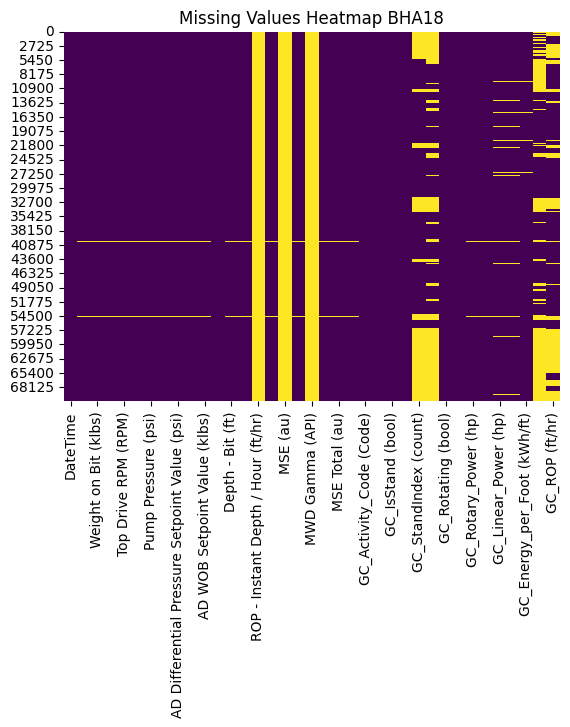

In [ ]:
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap BHA18")
plt.show()

-68.3923 206.83286


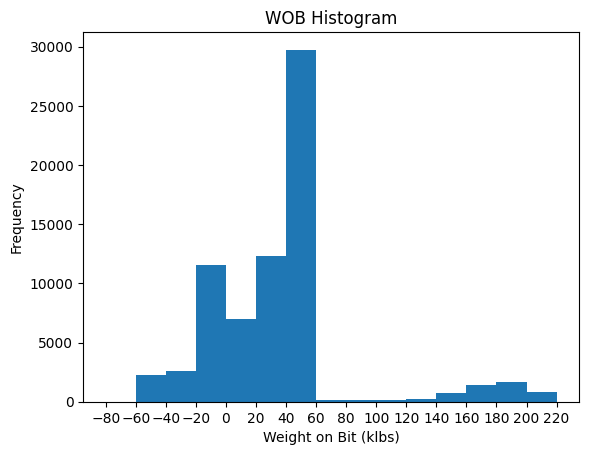

In [ ]:
WOB = data["Weight on Bit (klbs)"].dropna() # Drop NaN values to calculate min/max accurately
min_wob = WOB.min()
max_wob = WOB.max()
print(min_wob, max_wob)

# Create bins starting from 0, in steps of 20
bins = np.arange(-80, max_wob + 20, 20)

plt.hist(WOB, bins=bins)
plt.xlabel("Weight on Bit (klbs)")
plt.ylabel("Frequency")
plt.title("WOB Histogram")
plt.xticks(bins)
plt.show()

0.0 67.95699


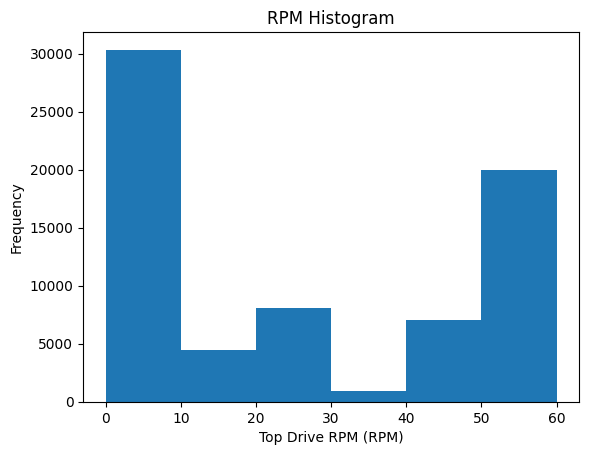

In [ ]:
RPM = data["Top Drive RPM (RPM)"].dropna()
min_RPM = RPM.min()
max_RPM = RPM.max()
print(min_RPM, max_RPM)

bins = np.arange(0, 70, 10)
plt.hist(RPM, bins=bins)
plt.xlabel("Top Drive RPM (RPM)")
plt.ylabel("Frequency")
plt.title("RPM Histogram")
plt.xticks(bins)
plt.show()

54254


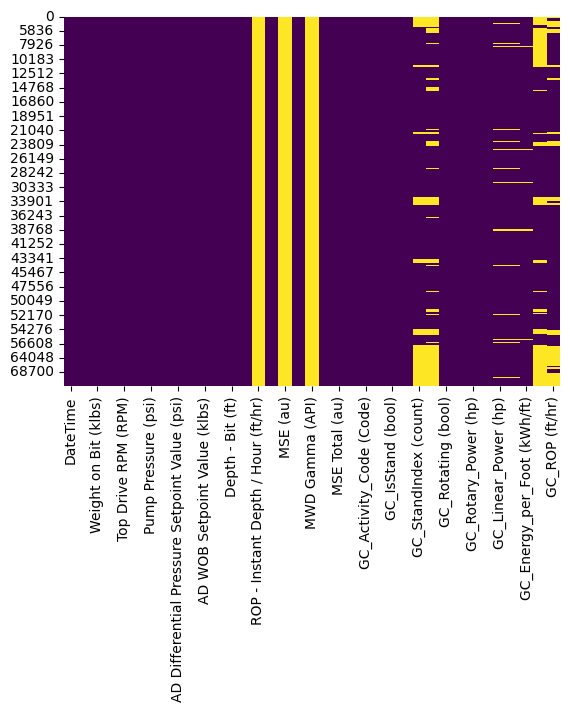

In [ ]:
WOB_mask = data[data["Weight on Bit (klbs)"] >= 0]
sns.heatmap(WOB_mask.isnull(), cbar=False, cmap='viridis')
print(len(WOB_mask))

In [ ]:
negative_wob_count = data[data["Weight on Bit (klbs)"] < 0].shape[0]
print(f"Number of negative 'Weight on Bit (klbs)' values: {negative_wob_count}")

Number of negative 'Weight on Bit (klbs)' values: 16482


In [ ]:
WOB_mask['DateTime'] = pd.to_datetime(WOB_mask['DateTime'])

/tmp/ipython-input-4214475794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WOB_mask['DateTime'] = pd.to_datetime(WOB_mask['DateTime'])


In [ ]:
WOB_mask = WOB_mask.set_index('DateTime')
min_dt = WOB_mask.index.min()
max_dt = WOB_mask.index.max()
date_range = pd.date_range(start=min_dt, end=max_dt, freq='1s')
WOB_reindexed = WOB_mask.reindex(date_range)

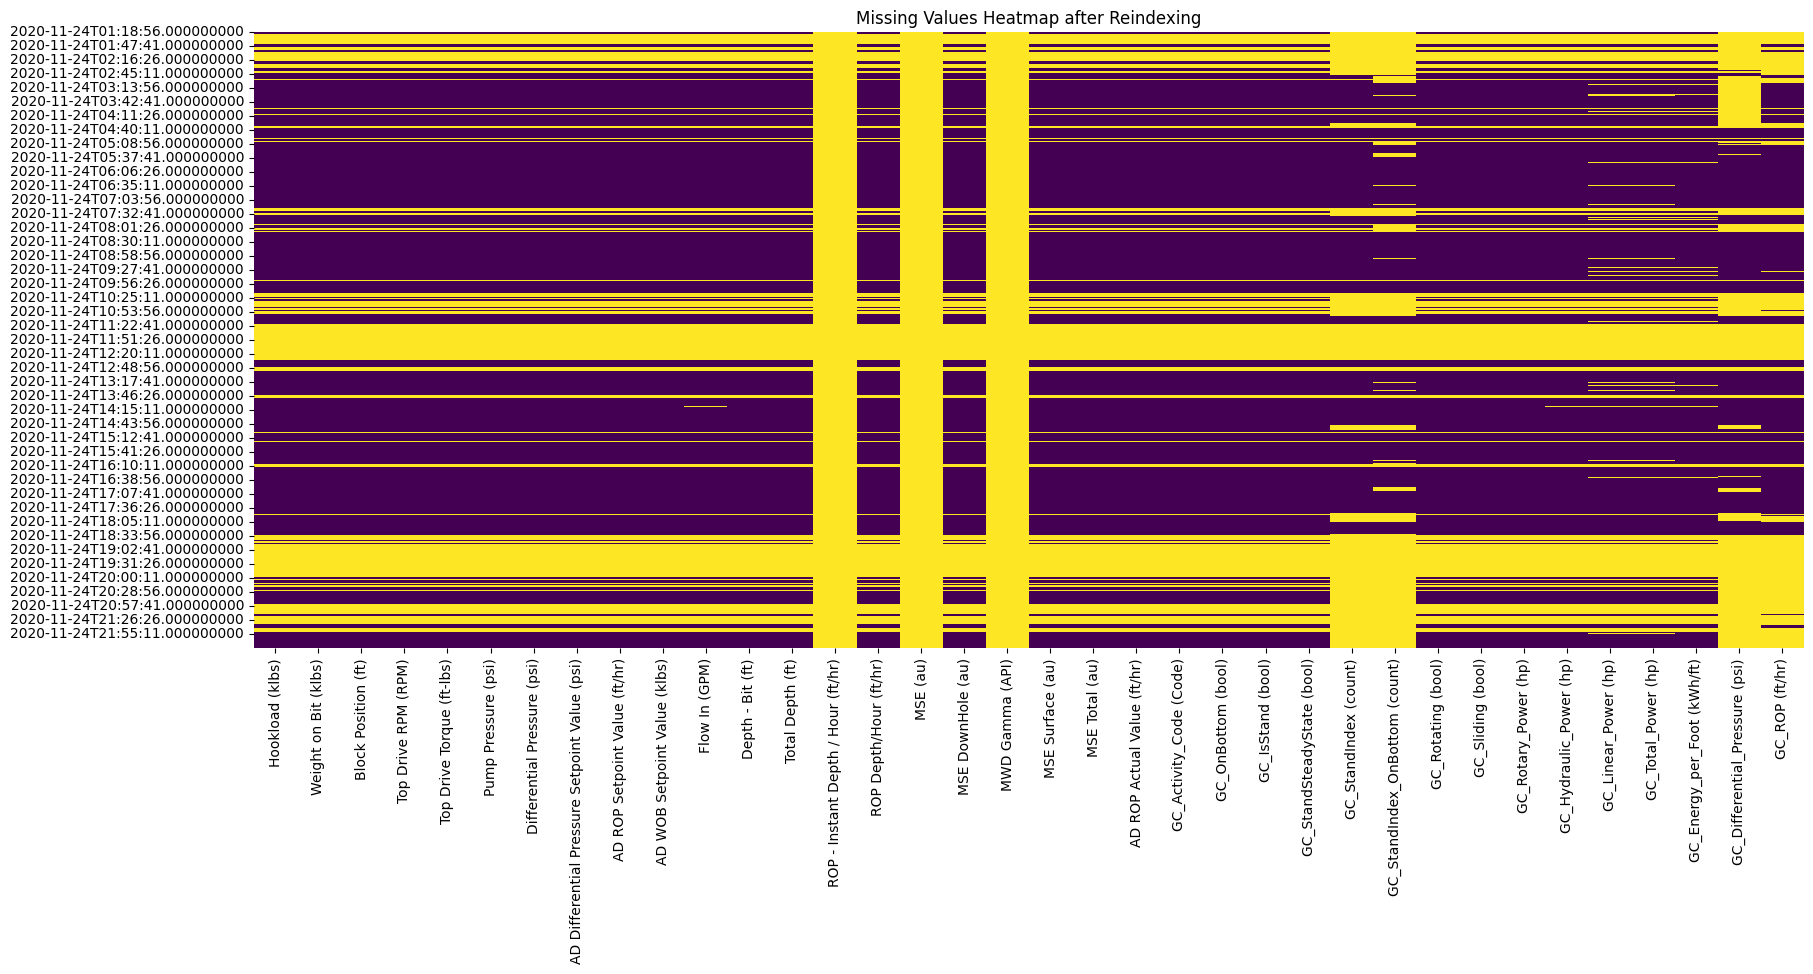

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(WOB_reindexed.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap after Reindexing")
plt.show()


70829


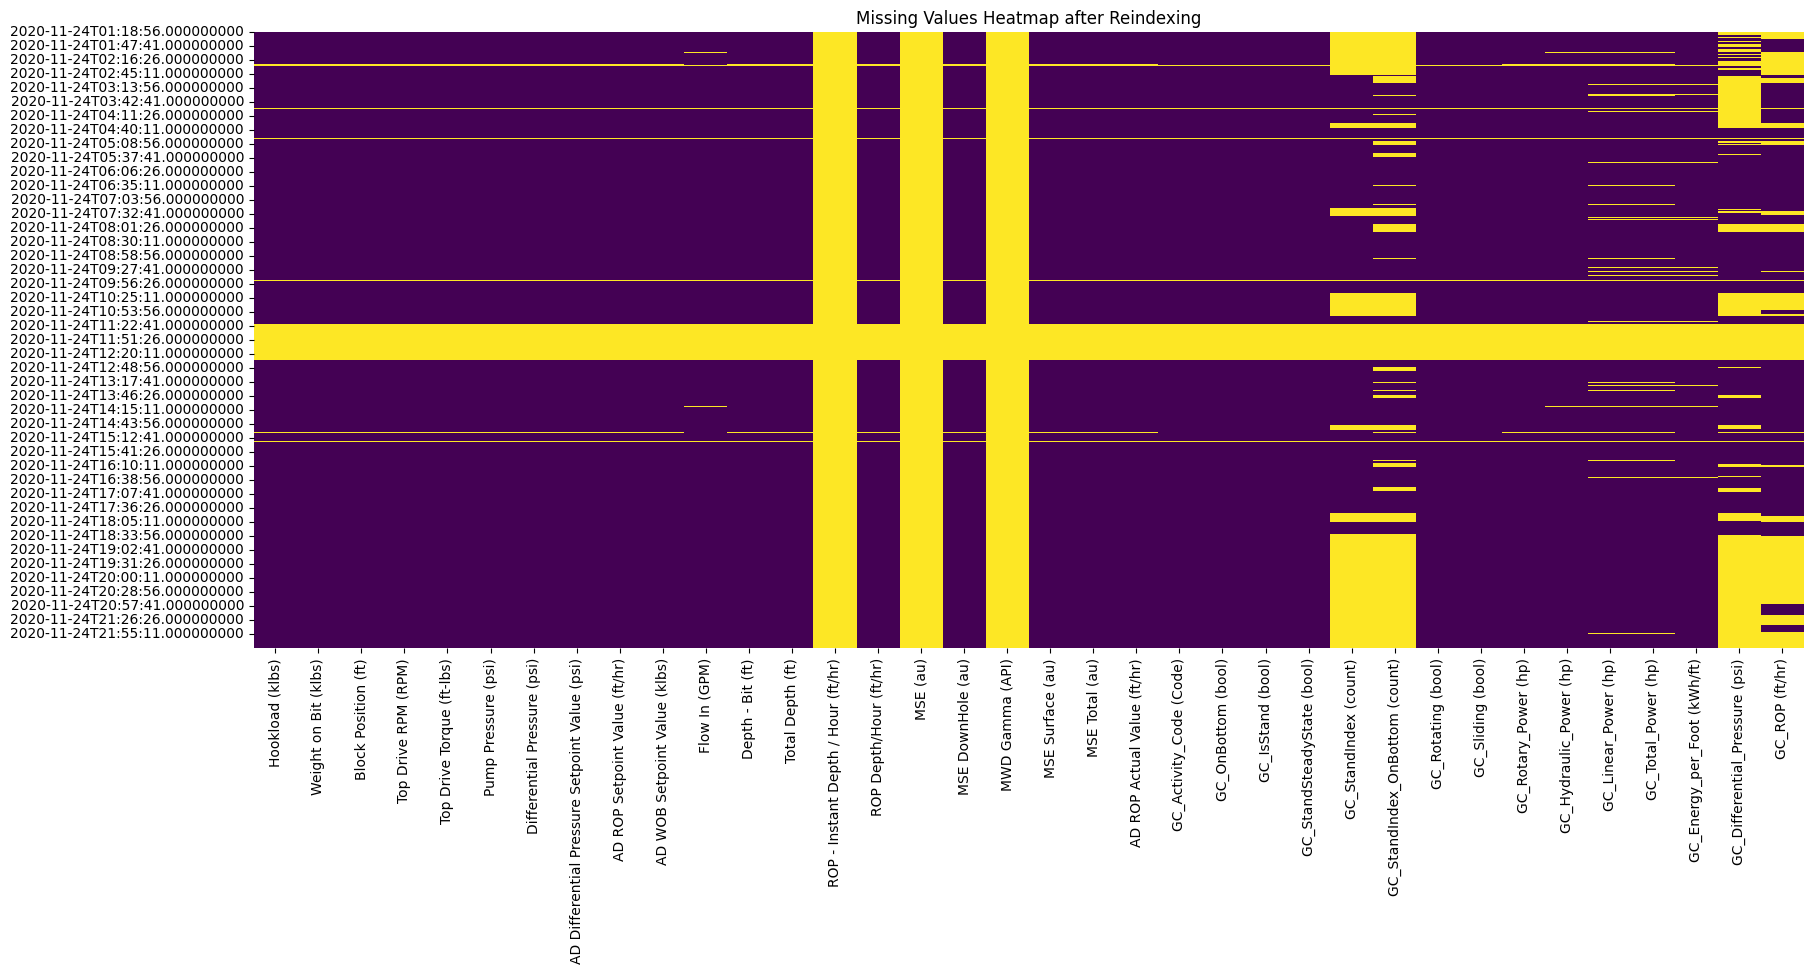

In [ ]:
data1 = pd.read_csv('vibrationdata_slice.csv', skiprows=37)
print(len(data1))
data1['DateTime'] = pd.to_datetime(data['DateTime'])
data1 = data1.set_index('DateTime')
min_dt = data1.index.min()
max_dt = data1.index.max()
date_range = pd.date_range(start=min_dt, end=max_dt, freq='1s')
data1_reindexed = data1.reindex(date_range)
plt.figure(figsize=(20, 8))
sns.heatmap(data1_reindexed.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap after Reindexing")
plt.show()

0.0 206.83286


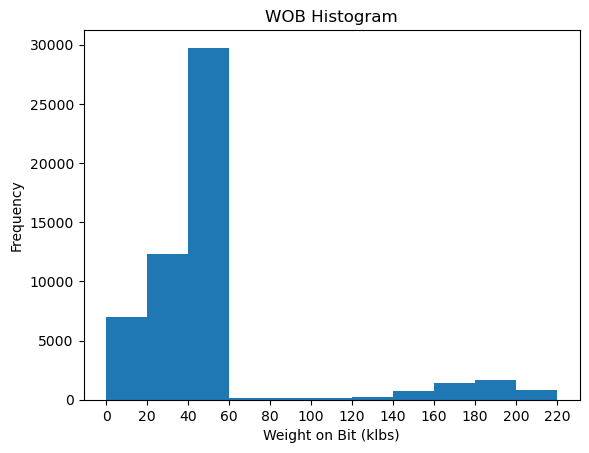

0.0 58.55792


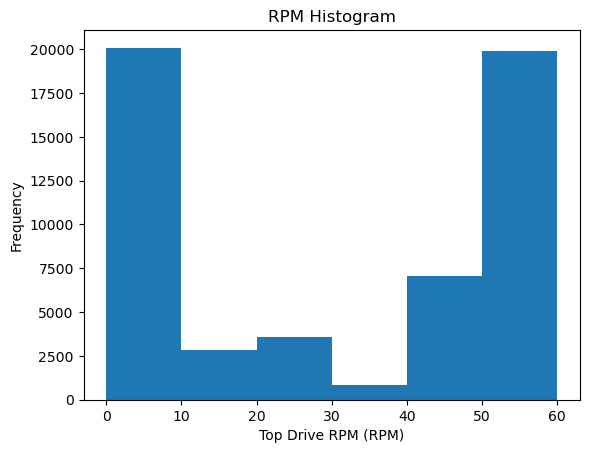

<class 'pandas.core.frame.DataFrame'>
Index: 54254 entries, 0 to 70828
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DateTime                                       54254 non-null  object 
 1   Hookload (klbs)                                54254 non-null  float64
 2   Weight on Bit (klbs)                           54254 non-null  float64
 3   Block Position (ft)                            54254 non-null  float64
 4   Top Drive RPM (RPM)                            54254 non-null  float64
 5   Top Drive Torque (ft-lbs)                      54254 non-null  float64
 6   Pump Pressure (psi)                            54254 non-null  float64
 7   Differential Pressure (psi)                    54254 non-null  float64
 8   AD Differential Pressure Setpoint Value (psi)  54254 non-null  float64
 9   AD ROP Setpoint Value (ft/hr)                  54254 no

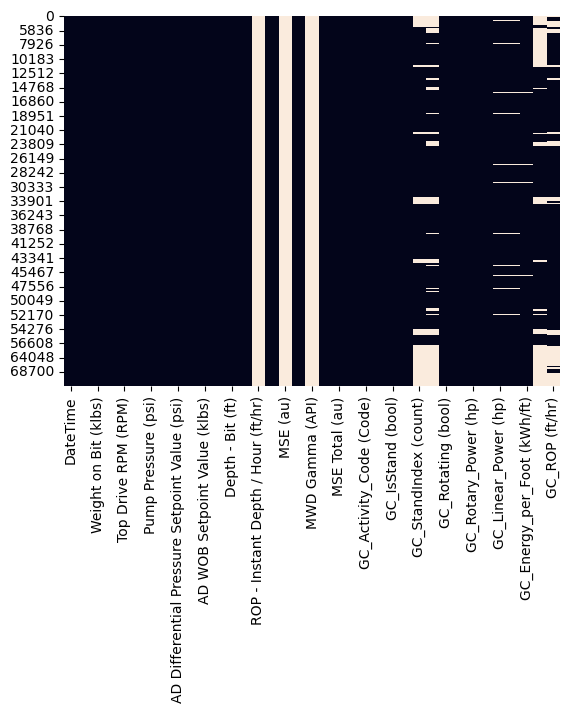

In [6]:
data2 = pd.read_csv('vibrationdata_slice.csv', skiprows=37)
data2 = data2[data2["Weight on Bit (klbs)"] >= 0]

WOB = data2["Weight on Bit (klbs)"].dropna() # Drop NaN values to calculate min/max accurately
min_wob = WOB.min()
max_wob = WOB.max()
print(min_wob, max_wob)

# Create bins starting from 0, in steps of 20
bins = np.arange(0, max_wob + 20, 20)

plt.hist(WOB, bins=bins)
plt.xlabel("Weight on Bit (klbs)")
plt.ylabel("Frequency")
plt.title("WOB Histogram")
plt.xticks(bins)
plt.show()

RPM = data2["Top Drive RPM (RPM)"].dropna()
min_RPM = RPM.min()
max_RPM = RPM.max()
print(min_RPM, max_RPM)

bins = np.arange(0, 70, 10)
plt.hist(RPM, bins=bins)
plt.xlabel("Top Drive RPM (RPM)")
plt.ylabel("Frequency")
plt.title("RPM Histogram")
plt.xticks(bins)
plt.show()

In [23]:
data3 = pd.read_csv("UofU 650-05-376 BHA 18 - output data.csv", skiprows=35)
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77976 entries, 0 to 77975
Data columns (total 63 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   DateTime                                              77976 non-null  object 
 1   Bit Box_GyroXmax(RPM)                                 72219 non-null  float64
 2   Bit Box_GyroXmed(RPM)                                 72219 non-null  float64
 3   Bit Box_Temperature(C)                                72219 non-null  float64
 4   Bit Box_ShXpeak(g)                                    72219 non-null  float64
 5   Bit Box_ShXrms(g)                                     72219 non-null  float64
 6   Bit Box_ShXmax(g)                                     72219 non-null  float64
 7   Bit Box_ShYpeak(g)                                    72219 non-null  float64
 8   Bit Box_ShYrms(g)                                     72

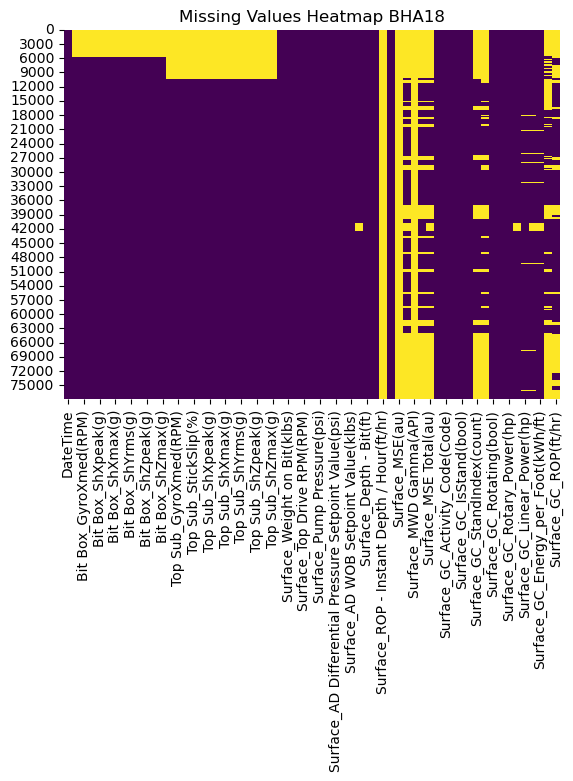

In [24]:
#data3 = data3[data3["Surface_Weight on Bit(klbs)"] >= 0]
missing_values = data3.isnull().sum()
sns.heatmap(data3.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap BHA18")
plt.show()

-68.3923 206.83286


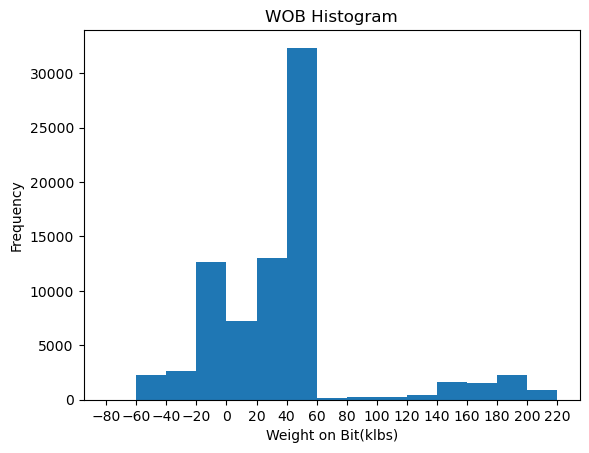

0.0 67.95699


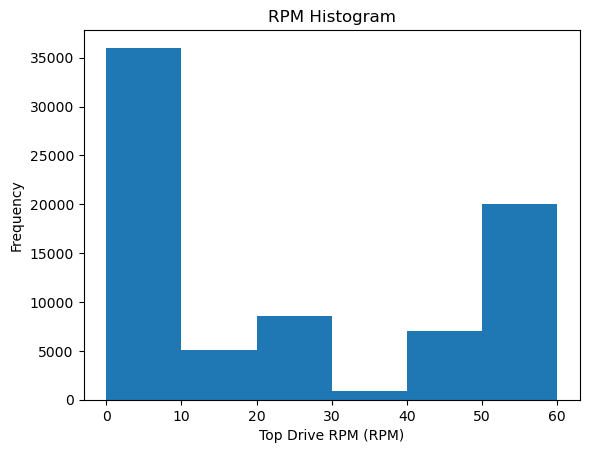

In [38]:
data3 = pd.read_csv("UofU 650-05-376 BHA 18 - output data.csv", skiprows=35)
WOB1 = data3["Surface_Weight on Bit(klbs)"].dropna() # Drop NaN values to calculate min/max accurately
min_wob = WOB1.min()
max_wob = WOB1.max()
print(min_wob, max_wob)

# Create bins starting from 0, in steps of 20
bins = np.arange(-80, max_wob + 20, 20)

plt.hist(WOB1, bins=bins)
plt.xlabel("Weight on Bit(klbs)")
plt.ylabel("Frequency")
plt.title("WOB Histogram")
plt.xticks(bins)
plt.show()

RPM1 = data3["Surface_Top Drive RPM(RPM)"].dropna()
min_RPM = RPM1.min()
max_RPM = RPM1.max()
print(min_RPM, max_RPM)

bins = np.arange(0, 70, 10)
plt.hist(RPM1, bins=bins)
plt.xlabel("Top Drive RPM (RPM)")
plt.ylabel("Frequency")
plt.title("RPM Histogram")
plt.xticks(bins)
plt.show()

Text(0.5, 1.0, 'Missing Data Values')

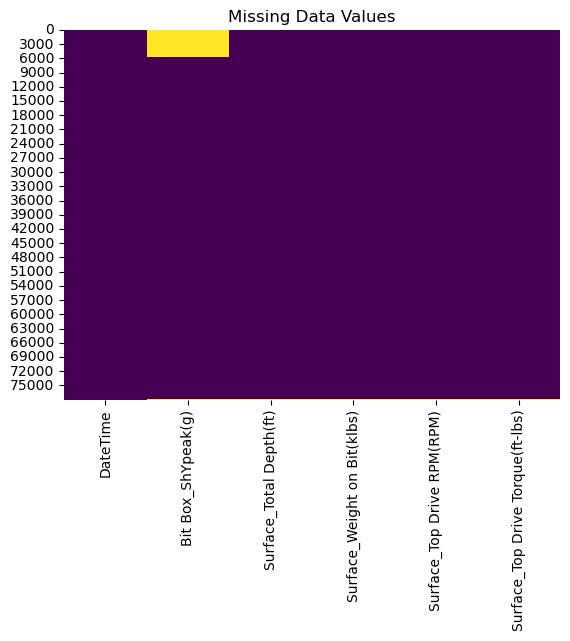

In [46]:
data3 = pd.read_csv("UofU 650-05-376 BHA 18 - output data.csv", skiprows = 35)
cleanedData = data3[["DateTime", "Bit Box_ShYpeak(g)", "Surface_Total Depth(ft)", "Surface_Weight on Bit(klbs)", "Surface_Top Drive RPM(RPM)", \
                    "Surface_Top Drive Torque(ft-lbs)"]]
sns.heatmap(cleanedData.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Values")

C:\Users\Isaac Xu\AppData\Local\Temp\ipykernel_1460\341556408.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleanedData["DateTime"] = pd.to_datetime(cleanedData["DateTime"])


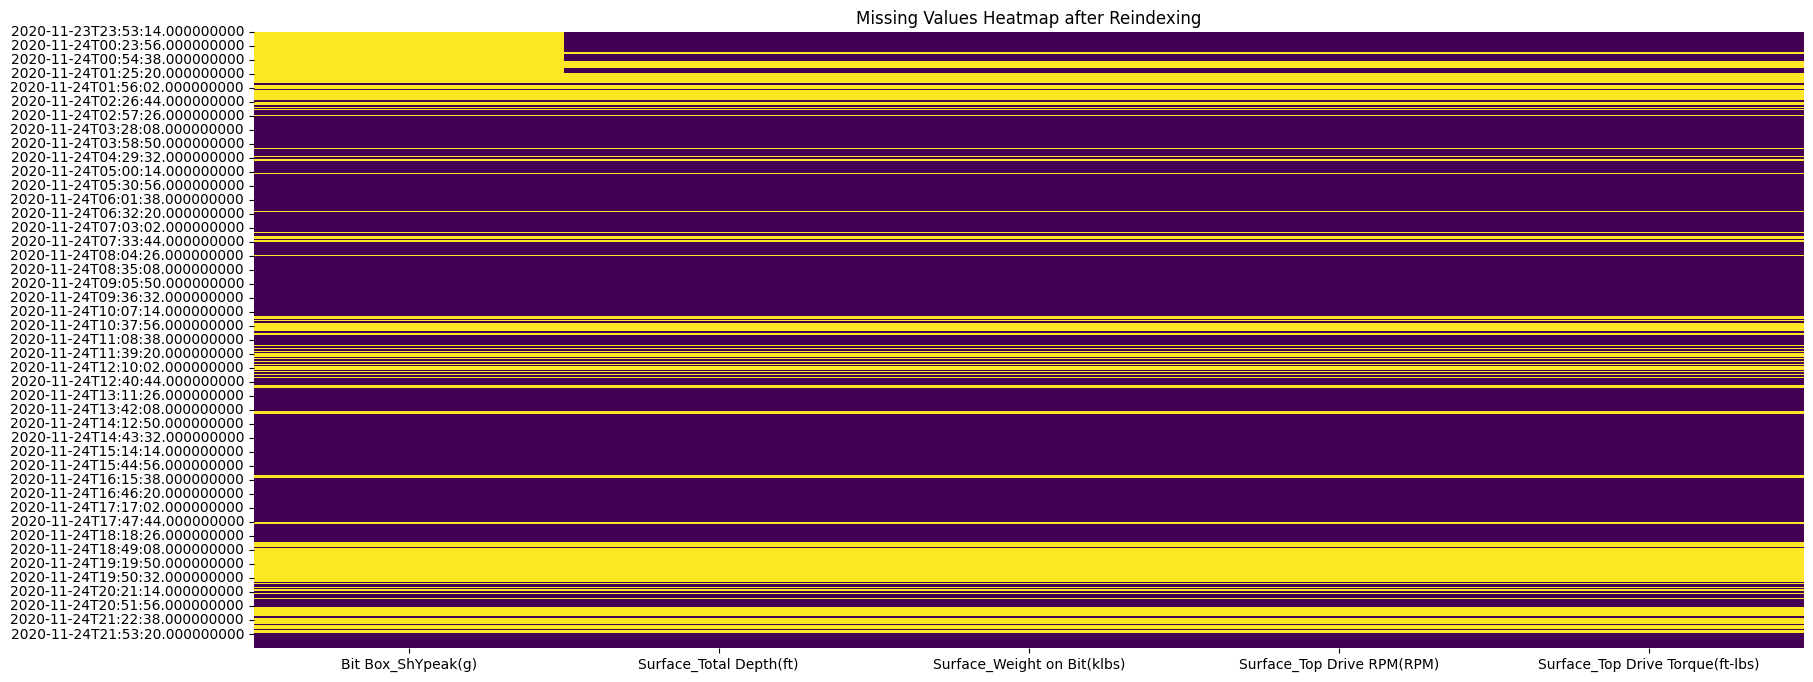

In [4]:
data3 = pd.read_csv("UofU 650-05-376 BHA 18 - output data.csv", skiprows = 35)
cleanedData = data3[["DateTime", "Bit Box_ShYpeak(g)", "Surface_Total Depth(ft)", "Surface_Weight on Bit(klbs)", "Surface_Top Drive RPM(RPM)", \
                    "Surface_Top Drive Torque(ft-lbs)"]]
cleanedData["DateTime"] = pd.to_datetime(cleanedData["DateTime"])
cleanedData = cleanedData[cleanedData["Surface_Weight on Bit(klbs)"] >= 0]
cleanedData = cleanedData.set_index("DateTime")
min_dt = cleanedData.index.min()
max_dt = cleanedData.index.max()
date_range = pd.date_range(start=min_dt, end=max_dt, freq='1s')
data1_reindexed = cleanedData.reindex(date_range)
plt.figure(figsize=(20, 8))
sns.heatmap(data1_reindexed.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap after Reindexing")
plt.show()

In [3]:
data3 = pd.read_csv("UofU 650-05-376 BHA 18 - output data.csv", skiprows = 35)
cleanedData = data3[["DateTime", "Bit Box_ShYpeak(g)", "Surface_Total Depth(ft)", "Surface_Weight on Bit(klbs)", "Surface_Top Drive RPM(RPM)", \
                    "Surface_Top Drive Torque(ft-lbs)"]]
cleanedData = cleanedData[(cleanedData["Surface_Weight on Bit(klbs)"] >= 0) & (cleanedData["Surface_Weight on Bit(klbs)"] <= 100)]
cleanedData = cleanedData.dropna()
cleanedData.to_csv("cleanedOutputBHA18.csv")
print(len(cleanedData))

51082


Text(0.5, 1.0, 'Frequency of Peak Shock in Y')

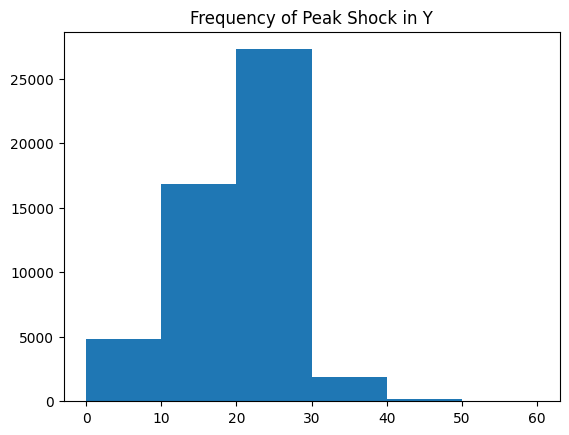

In [7]:
shMax = (cleanedData["Bit Box_ShYpeak(g)"]).max()
bins = np.arange(0, shMax + 10, 10)
plt.hist(cleanedData["Bit Box_ShYpeak(g)"], bins=bins)
plt.title("Frequency of Peak Shock in Y")

Text(0.5, 1.0, 'Frequency of WOB')

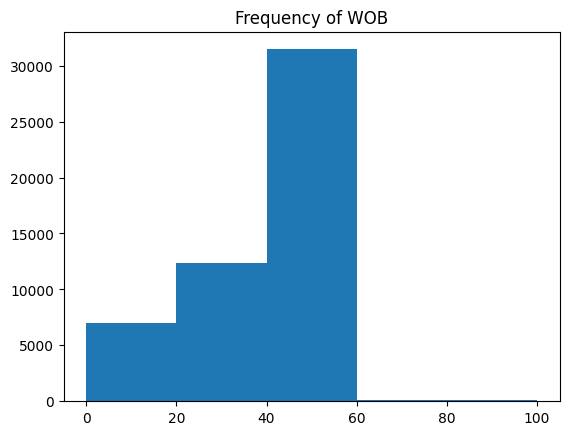

In [8]:
WOBMax = (cleanedData["Surface_Weight on Bit(klbs)"]).max()
bins = np.arange(0, WOBMax + 10, 20)
plt.hist(cleanedData["Surface_Weight on Bit(klbs)"], bins=bins)
plt.xticks(bins)
plt.title("Frequency of WOB")

Text(0.5, 1.0, 'Frequency of RPM')

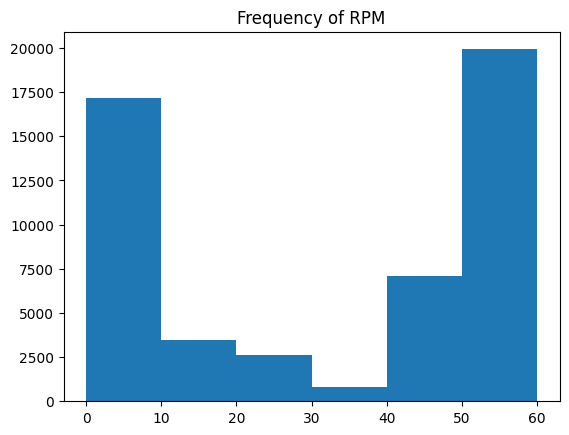

In [9]:
RPMMax = (cleanedData["Surface_Top Drive RPM(RPM)"]).max()
bins = np.arange(0, RPMMax + 10, 10)
plt.hist(cleanedData["Surface_Top Drive RPM(RPM)"], bins=bins)
plt.title("Frequency of RPM")

In [10]:
WOB_above60 = cleanedData[cleanedData["Surface_Weight on Bit(klbs)"] > 60]
print(len(WOB_above60))

218
